# 05 — Model Training

Entrenamiento de **XGBoost** y **CatBoost** para estimar turbidez superficial en Mar Menor.
---

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

import xgboost as xgb
from catboost import CatBoostRegressor

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
RANDOM_STATE = 42
print(xgb.__version__)

3.2.0


## 1. Configuración

In [26]:
BASE_DIR = Path('..')
FE_DIR   = BASE_DIR / 'data' / 'processed' / 'feature_engineering'
RES_DIR  = BASE_DIR / 'results'
MOD_DIR  = RES_DIR / 'models'
for d in [RES_DIR, MOD_DIR]:
    d.mkdir(exist_ok=True)

# ── Datasets a comparar (escala espacial de extracción de features) ─────────
# diameter_m: diámetro aprox. del área de extracción en metros
# radius_px : radio en píxeles (resolución 3 m/px)
DATASET_CONFIG = {
    'tabular_200m': {'file': 'fe_tabular.parquet',     'radius_px': 66,  'diameter_m': 400},
    'patch_16px':   {'file': 'fe_16px_stats.parquet',  'radius_px': 8,   'diameter_m': 48},
    'patch_32px':   {'file': 'fe_32px_stats.parquet',  'radius_px': 16,  'diameter_m': 96},
    'patch_64px':   {'file': 'fe_64px_stats.parquet',  'radius_px': 32,  'diameter_m': 192},
    'patch_128px':  {'file': 'fe_128px_stats.parquet', 'radius_px': 64,  'diameter_m': 384},
    'patch_256px':  {'file': 'fe_256px_stats.parquet', 'radius_px': 128, 'diameter_m': 768},
}

META_COLS    = ['ctd', 'date', 'turbidity', 'n_pixels']
TEST_FRAC    = 0.20   # 20 % de fechas más recientes → test
N_CV_SPLITS  = 5
EARLY_STOP   = 50    # rounds sin mejora → stop
N_MAX_ITERS  = 1000  # cota superior; early stopping decide el óptimo

# ── Hiperparámetros XGBoost ──────────────────────────────────────────────────
# Regularización: L1 (reg_alpha), L2 (reg_lambda), subsampling, profundidad max.
XGB_PARAMS = dict(
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=1,
    subsample=0.9,
    colsample_bytree=0.9,
    colsample_bylevel=0.9,
    gamma=0.0,
    reg_alpha=0.0,
    reg_lambda=2.0,
    max_delta_step=0,
    grow_policy="lossguide",
    objective="reg:pseudohubererror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

# ── Hiperparámetros CatBoost ─────────────────────────────────────────────────
CAT_PARAMS = dict(
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=6.0,
    min_data_in_leaf=1,
    random_strength=0.0,
    bagging_temperature=0.5,
    loss_function="MAE",
    eval_metric="MAE",
    bootstrap_type="Bayesian",
    random_seed=RANDOM_STATE,
    thread_count=-1,
    verbose=False,
)

print(f"Datasets: {list(DATASET_CONFIG.keys())}")

Datasets: ['tabular_200m', 'patch_16px', 'patch_32px', 'patch_64px', 'patch_128px', 'patch_256px']


## 2. Funciones utilitarias

In [8]:
def load_dataset(ds_name):
    """Carga un dataset de feature engineering; devuelve df limpio y lista de feature cols."""
    cfg  = DATASET_CONFIG[ds_name]
    df   = pd.read_parquet(FE_DIR / cfg['file'])
    df['date'] = pd.to_datetime(df['date'])
    df   = df.dropna(subset=['turbidity']).reset_index(drop=True)
    feat = [c for c in df.columns if c not in META_COLS]
    return df, feat


def temporal_split(df):
    """80/20 split por fecha (sin leakage temporal)."""
    dates   = sorted(df['date'].unique())
    n_test  = max(1, int(len(dates) * TEST_FRAC))
    tr_d    = dates[:-n_test]
    te_d    = dates[-n_test:]
    return (df[df['date'].isin(tr_d)].reset_index(drop=True),
            df[df['date'].isin(te_d)].reset_index(drop=True),
            tr_d, te_d)


def compute_metrics(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0.0)
    return dict(
        mae      = round(mean_absolute_error(y_true, y_pred), 4),
        rmse     = round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        r2       = round(r2_score(y_true, y_pred), 4),
        pearson_r = round(pearsonr(y_true, y_pred)[0], 4),
        mape     = round(np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100, 2),
        bias     = round(float(np.mean(y_pred - y_true)), 4),
    )


print("Funciones cargadas.")

Funciones cargadas.


In [18]:
def cv_early_stopping(model_type, X, y_log, groups,
                       n_splits=N_CV_SPLITS, early_stop=EARLY_STOP):
    """
    GroupKFold CV con early stopping.
    - Entrena en log1p(turbidez), evalua en escala original.
    - Devuelve predicciones OOF (log-escala), metricas por fold y best_iteration por fold.
    """
    if model_type not in ('XGBoost', 'CatBoost'):
        raise ValueError(f"model_type desconocido: {model_type}")

    kf       = GroupKFold(n_splits=n_splits)
    oof_log  = np.full(len(y_log), np.nan)
    fold_met = []
    best_its = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y_log, groups)):
        Xtr, Xval = X[tr_idx], X[val_idx]
        ytr, yval = y_log[tr_idx], y_log[val_idx]

        if model_type == 'XGBoost':
            m = xgb.XGBRegressor(
                n_estimators=N_MAX_ITERS,
                early_stopping_rounds=early_stop,
                **XGB_PARAMS
            )

            m.fit(
                Xtr, ytr,
                eval_set=[(Xval, yval)],
                verbose=False
            )
            bi       = m.best_iteration
            pred_log = m.predict(Xval)   # usa best_ntree_limit automaticamente

        else:  # CatBoost
            m = CatBoostRegressor(iterations=N_MAX_ITERS, **CAT_PARAMS)
            m.fit(Xtr, ytr,
                  eval_set=(Xval, yval),
                  early_stopping_rounds=early_stop,
                  verbose=False)
            bi       = m.get_best_iteration()
            pred_log = m.predict(Xval)

        oof_log[val_idx] = pred_log
        best_its.append(bi)

        pred_orig = np.maximum(np.expm1(pred_log), 0.0)
        y_orig    = np.expm1(yval)
        fold_met.append(compute_metrics(y_orig, pred_orig))

    return oof_log, fold_met, best_its


def train_final(model_type, X, y_log, best_its):
    """
    Modelo final sobre TODO el training set.
    Usa la media de las best_iterations de CV como n_estimators (sin early stopping).
    """
    if model_type not in ('XGBoost', 'CatBoost'):
        raise ValueError(f"model_type desconocido: {model_type}")

    n_iters = max(int(np.round(np.mean(best_its))) + 1, 5)

    if model_type == 'XGBoost':
        m = xgb.XGBRegressor(n_estimators=n_iters, **XGB_PARAMS)
        m.fit(X, y_log)
    else:  # CatBoost
        m = CatBoostRegressor(iterations=n_iters, **CAT_PARAMS)
        m.fit(X, y_log, verbose=False)

    return m, n_iters


def predict_orig(model, X):
    """Predice turbidez en escala original (expm1 + clip a 0)."""
    return np.maximum(np.expm1(model.predict(X)), 0.0)


print("CV y funciones de entrenamiento cargadas.")


CV y funciones de entrenamiento cargadas.


## 3. Resumen de datasets y split

In [11]:
summary_rows = []
for ds_name in DATASET_CONFIG:
    df, feat_cols = load_dataset(ds_name)
    tr_df, te_df, tr_d, te_d = temporal_split(df)
    summary_rows.append({
        'dataset': ds_name,
        'diameter_m': DATASET_CONFIG[ds_name]['diameter_m'],
        'n_features': len(feat_cols),
        'n_train': len(tr_df),
        'n_test': len(te_df),
        'train_from': str(tr_d[0].date()),
        'train_to': str(tr_d[-1].date()),
        'test_from': str(te_d[0].date()),
        'test_to': str(te_d[-1].date()),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.set_index('dataset'))

df_ref, _ = load_dataset('tabular_200m')
tr_ref, _, _, _ = temporal_split(df_ref)
y_ref = tr_ref['turbidity'].values


,diameter_m,n_features,n_train,n_test,train_from,train_to,test_from,test_to
dataset,,,,,,,,
tabular_200m,400,45,345,74,2021-08-24,2024-04-10,2024-04-24,2024-07-03
patch_16px,48,45,341,74,2021-08-24,2024-04-10,2024-04-24,2024-07-03
patch_32px,96,45,341,74,2021-08-24,2024-04-10,2024-04-24,2024-07-03
patch_64px,192,45,341,74,2021-08-24,2024-04-10,2024-04-24,2024-07-03
patch_128px,384,45,341,74,2021-08-24,2024-04-10,2024-04-24,2024-07-03
patch_256px,768,45,341,74,2021-08-24,2024-04-10,2024-04-24,2024-07-03


## 4. Loop de entrenamiento: XGBoost + CatBoost × 6 datasets

In [28]:
models_to_train = ['XGBoost', 'CatBoost']

all_results  = []
oof_records  = []
test_records = []

print(f"Entrenando {len(DATASET_CONFIG)} datasets × {len(models_to_train)} modelos "
      f"= {len(DATASET_CONFIG)*len(models_to_train)} combinaciones\n")

for ds_name, ds_cfg in DATASET_CONFIG.items():
    df, feat_cols = load_dataset(ds_name)
    tr_df, te_df, tr_d, te_d = temporal_split(df)

    X_tr   = tr_df[feat_cols].values.astype(np.float64)
    X_te   = te_df[feat_cols].values.astype(np.float64)
    y_tr   = tr_df['turbidity'].values
    y_te   = te_df['turbidity'].values
    y_tr_l = np.log1p(y_tr)                              # target en log-escala
    groups = pd.Categorical(tr_df['date']).codes         # grupos por fecha

    for mtype in models_to_train:
        print(f"  [{ds_name}] {mtype} ...", end=' ', flush=True)

        # ── Cross-validation ─────────────────────────────────────────────────
        oof_log, fold_met, best_its = cv_early_stopping(
            mtype, X_tr, y_tr_l, groups)

        # ── Modelo final (n_iters = media de best_iterations del CV) ─────────
        final_model, n_iters = train_final(mtype, X_tr, y_tr_l, best_its)

        # ── Métricas test ────────────────────────────────────────────────────
        te_pred  = predict_orig(final_model, X_te)
        te_met   = compute_metrics(y_te, te_pred)

        # ── Métricas CV (media y std entre folds) ────────────────────────────
        cv_mae      = float(np.mean([m['mae']  for m in fold_met]))
        cv_mae_std  = float(np.std([m['mae']   for m in fold_met]))
        cv_rmse     = float(np.mean([m['rmse'] for m in fold_met]))
        cv_r2       = float(np.mean([m['r2']   for m in fold_met]))

        # ── OOF sobre escala original ────────────────────────────────────────
        oof_orig = np.maximum(np.expm1(oof_log), 0.0)
        oof_met  = compute_metrics(y_tr, oof_orig)

        print(f"n_iters={n_iters:4d}  "
              f"test_MAE={te_met['mae']:.3f}  "
              f"CV_MAE={cv_mae:.3f}±{cv_mae_std:.3f}  "
              f"OOF_MAE={oof_met['mae']:.3f}")

        # ── Guardar modelo ───────────────────────────────────────────────────
        model_key = f'{ds_name}__{mtype}'
        pickle.dump(final_model, open(MOD_DIR / f'{model_key}.pkl', 'wb'))
        pickle.dump(feat_cols, open(MOD_DIR / f'{ds_name}__feat_cols.pkl', 'wb'))

        # ── Registro de métricas ─────────────────────────────────────────────
        all_results.append({
            'dataset': ds_name, 'diameter_m': ds_cfg['diameter_m'],
            'model': mtype, 'n_train': len(tr_df), 'n_test': len(te_df),
            'n_iters': n_iters,
            **{f'test_{k}': v for k, v in te_met.items()},
            **{f'oof_{k}':  v for k, v in oof_met.items()},
            'cv_mae': round(cv_mae, 4), 'cv_mae_std': round(cv_mae_std, 4),
            'cv_rmse': round(cv_rmse, 4), 'cv_r2': round(cv_r2, 4),
            'best_iter_mean': round(np.mean(best_its), 1),
            'best_iter_std':  round(np.std(best_its), 1),
        })

        # ── Predicciones test ────────────────────────────────────────────────
        for idx, (row_df, pred_val) in enumerate(zip(te_df.itertuples(), te_pred)):
            test_records.append({
                'ctd': row_df.ctd, 'date': row_df.date,
                'turbidity': row_df.turbidity, 'pred': pred_val,
                'dataset': ds_name, 'model': mtype,
            })

        # ── Predicciones OOF ─────────────────────────────────────────────────
        for idx, (row_df, oof_val) in enumerate(zip(tr_df.itertuples(), oof_orig)):
            oof_records.append({
                'ctd': row_df.ctd, 'date': row_df.date,
                'turbidity': row_df.turbidity, 'pred': oof_val,
                'dataset': ds_name, 'model': mtype,
            })

print("\nEntrenamiento finalizado.")

Entrenando 6 datasets × 2 modelos = 12 combinaciones

  [tabular_200m] XGBoost ... n_iters= 102  test_MAE=0.566  CV_MAE=0.774±0.220  OOF_MAE=0.773
  [tabular_200m] CatBoost ... n_iters=  37  test_MAE=0.549  CV_MAE=0.805±0.441  OOF_MAE=0.802
  [patch_16px] XGBoost ... n_iters= 140  test_MAE=0.636  CV_MAE=0.746±0.249  OOF_MAE=0.743
  [patch_16px] CatBoost ... n_iters= 203  test_MAE=0.574  CV_MAE=0.761±0.412  OOF_MAE=0.756
  [patch_32px] XGBoost ... n_iters= 261  test_MAE=0.610  CV_MAE=0.767±0.231  OOF_MAE=0.764
  [patch_32px] CatBoost ... n_iters= 149  test_MAE=0.539  CV_MAE=0.785±0.418  OOF_MAE=0.780
  [patch_64px] XGBoost ... n_iters= 138  test_MAE=0.551  CV_MAE=0.783±0.218  OOF_MAE=0.780
  [patch_64px] CatBoost ... n_iters= 107  test_MAE=0.557  CV_MAE=0.782±0.415  OOF_MAE=0.777
  [patch_128px] XGBoost ... n_iters= 127  test_MAE=0.540  CV_MAE=0.711±0.250  OOF_MAE=0.708
  [patch_128px] CatBoost ... n_iters= 101  test_MAE=0.549  CV_MAE=0.782±0.430  OOF_MAE=0.777
  [patch_256px] XGBoost .

## 5. Tabla de resultados

In [29]:
metrics_df = pd.DataFrame(all_results)

# Guardar
metrics_df.to_csv(RES_DIR / 'model_metrics.csv', index=False)
pd.DataFrame(test_records).to_csv(RES_DIR / 'test_predictions.csv', index=False)
pd.DataFrame(oof_records).to_csv(RES_DIR  / 'oof_predictions.csv',  index=False)

# Mostrar tabla con métricas clave
cols_show = ['dataset', 'model', 'test_mae', 'test_rmse', 'test_r2',
             'cv_mae', 'cv_mae_std', 'oof_mae', 'n_iters']
display(metrics_df[cols_show].sort_values('test_mae').reset_index(drop=True))

,dataset,model,test_mae,test_rmse,test_r2,cv_mae,cv_mae_std,oof_mae,n_iters
0,patch_256px,CatBoost,0.5368,0.6629,-0.2386,0.8059,0.4391,0.8014,67
1,patch_32px,CatBoost,0.5393,0.6717,-0.2715,0.7847,0.4180,0.7801,149
2,patch_128px,XGBoost,0.5405,0.6773,-0.2928,0.7111,0.2501,0.7083,127
3,patch_128px,CatBoost,0.5489,0.6654,-0.2476,0.7821,0.4304,0.7775,101
4,tabular_200m,CatBoost,0.5493,0.6528,-0.2008,0.8050,0.4411,0.8024,37
5,patch_64px,XGBoost,0.5511,0.7277,-0.4924,0.7828,0.2175,0.7803,138
6,patch_64px,CatBoost,0.5568,0.6790,-0.2993,0.7820,0.4149,0.7774,107
7,tabular_200m,XGBoost,0.5662,0.7152,-0.4416,0.7744,0.2201,0.7726,102
8,patch_16px,CatBoost,0.5744,0.7119,-0.4283,0.7607,0.4120,0.7562,203
9,patch_32px,XGBoost,0.6096,0.8123,-0.8596,0.7665,0.2310,0.7636,261


## 6. Visualización rápida de resultados

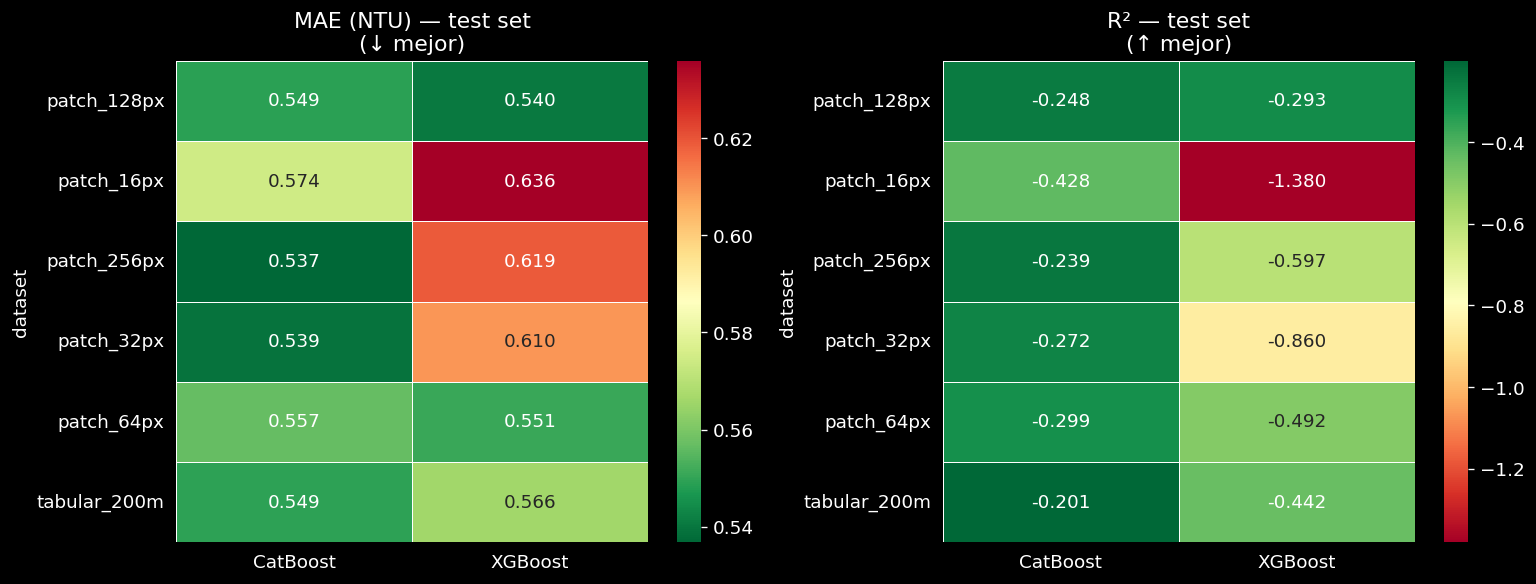

In [30]:
# Heatmap: MAE test por dataset × modelo
pivot_mae = metrics_df.pivot(index='dataset', columns='model', values='test_mae')
pivot_r2  = metrics_df.pivot(index='dataset', columns='model', values='test_r2')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(pivot_mae, annot=True, fmt='.3f', cmap='RdYlGn_r',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('MAE (NTU) — test set\n(↓ mejor)')
axes[0].set_xlabel('')

sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('R² — test set\n(↑ mejor)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig(RES_DIR / 'training_heatmap.png', bbox_inches='tight')
plt.show()

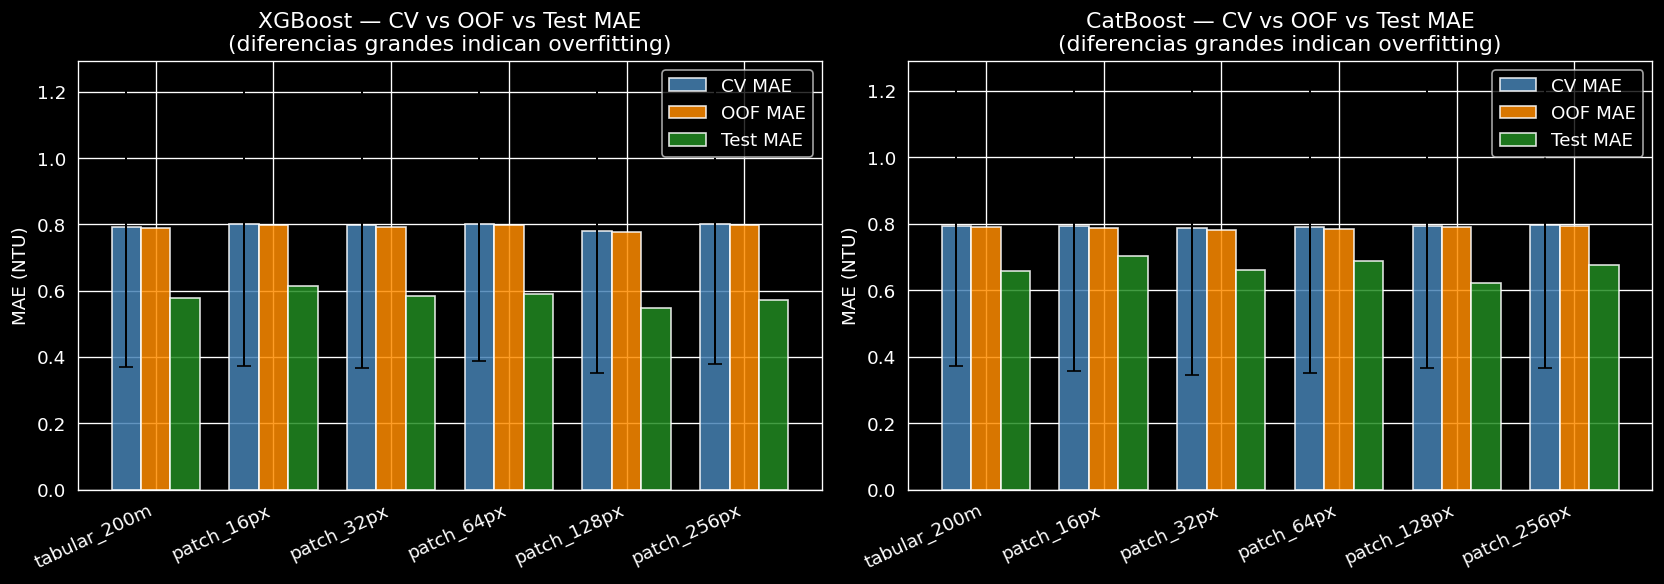

In [22]:
# Overfitting check: CV_MAE vs Test_MAE vs OOF_MAE
fig, axes = plt.subplots(1, len(models_to_train), figsize=(7 * len(models_to_train), 5))
if len(models_to_train) == 1:
    axes = [axes]

for ax, mtype in zip(axes, models_to_train):
    sub = metrics_df[metrics_df['model'] == mtype].copy()
    x   = np.arange(len(sub))
    w   = 0.25
    ax.bar(x - w, sub['cv_mae'],   width=w, label='CV MAE',   color='steelblue', alpha=0.85)
    ax.bar(x,     sub['oof_mae'],  width=w, label='OOF MAE',  color='darkorange', alpha=0.85)
    ax.bar(x + w, sub['test_mae'], width=w, label='Test MAE', color='forestgreen', alpha=0.85)
    ax.errorbar(x - w, sub['cv_mae'], yerr=sub['cv_mae_std'],
                fmt='none', color='black', capsize=4, linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(sub['dataset'], rotation=25, ha='right')
    ax.set_ylabel('MAE (NTU)')
    ax.set_title(f'{mtype} — CV vs OOF vs Test MAE\n(diferencias grandes indican overfitting)')
    ax.legend()

plt.tight_layout()
plt.savefig(RES_DIR / 'training_overfitting_check.png', bbox_inches='tight')
plt.show()

## 7. Mejor combinación y config para notebooks 06 y 07

In [23]:
# Mejor combinación por MAE test
best_row = metrics_df.loc[metrics_df['test_mae'].idxmin()]
best_ds  = best_row['dataset']
best_mod = best_row['model']

print(f"Mejor combinación: dataset={best_ds}  modelo={best_mod}")
print(f"  Test MAE={best_row['test_mae']:.4f}  RMSE={best_row['test_rmse']:.4f}  "
      f"R²={best_row['test_r2']:.4f}  r={best_row['test_pearson_r']:.4f}")

# Guardar config para notebook 07
best_cfg = {
    'best_dataset':   best_ds,
    'best_model':     best_mod,
    'radius_px':      int(DATASET_CONFIG[best_ds]['radius_px']),
    'diameter_m':     int(DATASET_CONFIG[best_ds]['diameter_m']),
    'model_file':     f'{best_ds}__{best_mod}.pkl',
    'feat_cols_file': f'{best_ds}__feat_cols.pkl',
    # También guardar tabular_200m como opción de mapa (más eficiente)
    'map_dataset':    best_ds,
    'map_radius_px':  int(DATASET_CONFIG[best_ds]['radius_px']),
}
with open(RES_DIR / 'best_model_info.json', 'w') as f:
    json.dump(best_cfg, f, indent=2)

# Guardar config de datasets para notebook 07
with open(RES_DIR / 'dataset_config.json', 'w') as f:
    json.dump(DATASET_CONFIG, f, indent=2)

print("\nArchivos guardados en results/:")
print("  model_metrics.csv")
print("  test_predictions.csv")
print("  oof_predictions.csv")
print("  best_model_info.json")
print("  dataset_config.json")
print(f"  models/{best_ds}__{best_mod}.pkl  (+ {len(DATASET_CONFIG)*len(models_to_train)-1} más)")

Mejor combinación: dataset=patch_128px  modelo=XGBoost
  Test MAE=0.5465  RMSE=0.6806  R²=-0.3055  r=0.3308

Archivos guardados en results/:
  model_metrics.csv
  test_predictions.csv
  oof_predictions.csv
  best_model_info.json
  dataset_config.json
  models/patch_128px__XGBoost.pkl  (+ 11 más)
